<a href="https://colab.research.google.com/github/peteparker123/Agentic-RAG/blob/main/agentic_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install Dependencies

In [ ]:
!pip install -q langgraph langchain-google-genai langchain
!pip install -q langchain langchain-text-splitters pypdf chromadb langchain_community
!pip install -q langchain-huggingface

## 2. Imports

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate
from langchain.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Sequence
import os
import shutil
from google.colab import files
import uuid

/tmp/ipykernel_911/1611495485.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


## 3. Configuration

In [ ]:
# ── API Keys (use 4 separate Google AI Studio keys to avoid rate limits) ──────
# Each key has a free tier of 20 req/day for gemini-2.5-flash
# Generate keys at: https://aistudio.google.com/app/apikey
GOOGLE_API_KEY_RAG     = "your gemini api key"   # used by RAG tool
GOOGLE_API_KEY_SEARCH  = "your gemini api key"   # used by web_search tool
GOOGLE_API_KEY_GENERAL = "your gemini api key"   # used by general tool
GOOGLE_API_KEY_ROUTER  = "your gemini api key"   # used by agent router

# ── ChromaDB persist directory ────────────────────────────────────────────
CHROMA_DIR = "./chroma_langchain_db"

# ── Embedding model ────────────────────────────────────────────
EMBEDDING_MODEL_NAME = "BAAI/bge-small-en"
EMBEDDING_DEVICE     = "cuda"            # change to "cpu" if no GPU

# ── Retriever settings ───────────────────────────────────────────
CHUNK_SIZE    = 1000
CHUNK_OVERLAP = 300
TOP_K         = 5

## 4. State Schema

In [ ]:
class State(TypedDict):
    # add_messages reducer appends new messages instead of overwriting
    messages: Annotated[Sequence[BaseMessage], add_messages]

## 5. Dynamic Document Upload & Vector Store

Upload any PDF at runtime using the file picker below.  
The vector store is **rebuilt automatically** on each new upload,
so you can swap documents without restarting the kernel.

In [ ]:
# ── Global state ──────────────────────────────────────────────────────────
retriever        = None
current_chroma   = None   # tracks the active Chroma client so we can close it

def build_retriever(pdf_path: str) -> object:
    """Load PDF, split, embed, store in a fresh UUID-named ChromaDB, return retriever."""
    global current_chroma

    # 1. Load PDF
    pdf_loader = PyPDFLoader(pdf_path)
    documents  = pdf_loader.load()

    if not documents:
        raise ValueError(
            f"No text extracted from '{pdf_path}'. "
            "The file may be a scanned/image PDF — OCR is required for those."
        )

    # 2. Split into chunks
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        length_function=len,
        add_start_index=True,
    )
    all_splits = text_splitter.split_documents(documents)

    # 3. Create embedding model
    embedding_model = HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL_NAME,
        model_kwargs={"device": EMBEDDING_DEVICE},
        encode_kwargs={"normalize_embeddings": True},
    )

    # 4. Close the previous Chroma client to release the SQLite lock
    if current_chroma is not None:
        try:
            current_chroma._client._system.stop()
        except Exception:
            pass
        current_chroma = None

    # 5. Each upload gets its own UUID directory — no lock conflicts
    chroma_dir = f"./chroma_{uuid.uuid4().hex}"
    print(f"ChromaDB dir   : {chroma_dir}")

    # 6. Build / persist Chroma vector store
    vector_store = Chroma.from_documents(
        all_splits,
        embedding_model,
        persist_directory=chroma_dir,
    )
    current_chroma = vector_store

    # 7. Return retriever
    retriever = vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={"k": TOP_K},
    )
    return retriever


def upload_and_index():
    """
    Show a Colab file-picker, save the uploaded PDF to /content/,
    rebuild the vector store in a fresh ChromaDB dir, update the global retriever.
    """
    global retriever

    print("Please upload a PDF file...")
    uploaded = files.upload()                         # opens the file-picker

    if not uploaded:
        print("No file uploaded. Retriever unchanged.")
        return

    for filename, content in uploaded.items():
        if not filename.lower().endswith(".pdf"):
            print(f"Skipping '{filename}' — only PDF files are supported.")
            continue

        # Save to /content/
        pdf_path = f"/content/{filename}"
        with open(pdf_path, "wb") as f:
            f.write(content)
        print(f"Saved          : {pdf_path}  ({len(content):,} bytes)")

        # Rebuild vector store in a new UUID dir
        print("Building vector store... (this may take ~30s)")
        retriever = build_retriever(pdf_path)
        print(f"Vector store ready — document: '{filename}'")
        break    # process only the first PDF if multiple are uploaded


# ── Run upload on cell execution ──────────────────────────────────────────
upload_and_index()

Please upload a PDF file...


Saving my_letter_finale.pdf to my_letter_finale (1).pdf
Saved          : /content/my_letter_finale (1).pdf  (2,819 bytes)
Building vector store... (this may take ~30s)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ChromaDB dir   : ./chroma_a9c3f18157d34e06a7162e05882928e3
Vector store ready — document: 'my_letter_finale (1).pdf'


## 6. LLM Initialisation

In [ ]:
# Base LLM for RAG tool — uses RAG API key
llm_rag = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=GOOGLE_API_KEY_RAG,
)

# LLM for general tool — uses General API key
llm_general = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=GOOGLE_API_KEY_GENERAL,
)

## 7. Tool Definitions

In [ ]:
# ── Helper: format retrieved docs with page references ────────────────────
def format_docs(docs: list) -> str:
    formatted    = []
    seen_content = set()
    for doc in docs:
        page_num = doc.metadata.get("page", 0)
        content  = doc.page_content.strip()
        if content not in seen_content:          # deduplicate chunks
            seen_content.add(content)
            formatted.append(f"[Page {page_num + 1}]: {content}")
    return "\n\n".join(formatted)


# ── RAG prompt template ────────────────────────────────────────────
rag_prompt = ChatPromptTemplate.from_messages([
    SystemMessage(
        content=(
            "Provide a factual, safe, and professional response. "
            "You are a helpful and knowledgeable general assistant chatbot. "
            "Answer ONLY using the provided context. "
            "Explain the answer clearly in 3 to 4 well-structured sentences. "
            "Include key details and slightly elaborate the concept. "
            "Do not give one-line answers. "
            "Each piece of context is prefixed with its page number like [Page 3]. "
            "Naturally include page references like (p. 3) within your answer "
            "when citing specific information — do not overuse them, only cite the most relevant pages. "
            "If the answer is not present in the context, respond with "
            "'The answer is not available in the document.'"
        )
    ),
    HumanMessagePromptTemplate.from_template(
        "Context:\n{context}\n\nQuestion:\n{question}"
    ),
])


# ── Tool 1 : RAG ──────────────────────────────────────────────────
@tool
def rag(query: str) -> str:
    """Retrieve information from the document and answer the query."""
    if retriever is None:
        return "No document uploaded yet. Please run the upload cell first."

    docs    = retriever.invoke(query)
    context = format_docs(docs)

    prompt_value = rag_prompt.invoke({"context": context, "question": query})
    response     = llm_rag.invoke(prompt_value)
    return response.content


# ── Tool 2 : Web Search ───────────────────────────────────────────────
@tool
def web_search(query: str) -> str:
    """Do real-time web search using Gemini's built-in Google Search tool."""
    search_llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        api_key=GOOGLE_API_KEY_SEARCH,
    ).bind_tools([{"google_search": {}}])

    response = search_llm.invoke(query)
    return response.content


# ── Tool 3 : General Question ───────────────────────────────────────────────
@tool
def general(query: str) -> str:
    """Answer a general question directly using the LLM's knowledge."""
    response = llm_general.invoke(query)
    return response.content


tools = [rag, web_search, general]
print("Tools defined:", [t.name for t in tools])

Tools defined: ['rag', 'web_search', 'general']


## 8. Bind Tools to LLM

In [ ]:
llm_with_tools = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=GOOGLE_API_KEY_ROUTER,
).bind_tools(tools)

## 9. Graph Nodes & Routing

In [ ]:
SYSTEM_PROMPT = SystemMessage(
    content=(
        "You are an AI assistant that can retrieve information from documents, "
        "perform real-time web searches, and answer general questions. "
        "Always call the most relevant tool based on the user's query. "
        "Use 'rag' for document-related questions, 'web_search' for current events "
        "or recent information, and 'general' for everything else."
    )
)


def llm_node(state: State) -> State:
    """Agent node — decides which tool to call (or returns a final answer)."""
    messages = [SYSTEM_PROMPT] + list(state["messages"])
    result   = llm_with_tools.invoke(messages)

    print("[agent] response:", result)
    print("[agent] tool_calls:", result.tool_calls)

    return {"messages": [result]}


def should_continue(state: State) -> str:
    """Router — send to tools if there are tool calls, else end."""
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "continue"
    return "end"


tool_node = ToolNode(tools)

## 10. Build & Compile the Graph

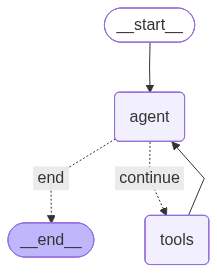

In [ ]:
graph = StateGraph(State)

# Nodes
graph.add_node("agent", llm_node)
graph.add_node("tools", tool_node)

# Edges
graph.add_edge(START, "agent")

graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "agent")

app = graph.compile()
app

## 11. Run the Agent

In [ ]:
def run_agent(user_query: str) -> str:
    """Invoke the agent and return the final answer."""
    inputs = {"messages": [HumanMessage(content=user_query)]}
    result = app.invoke(inputs)

    final_message = result["messages"][-1]

    # Handle both plain string and list-of-blocks content (Gemini 2.5 thinking model)
    if isinstance(final_message.content, list):
        return " ".join(
            block["text"]
            for block in final_message.content
            if isinstance(block, dict) and block.get("type") == "text"
        )
    return final_message.content

## 12. Upload a New Document (Re-run Anytime)

Run this cell whenever you want to **swap the document** without restarting the kernel.
The old vector store is wiped and rebuilt automatically.

In [ ]:
upload_and_index()

## 13. Query Examples

In [ ]:
# RAG query
print("=" * 60)
print("RAG Query")
print("=" * 60)
answer = run_agent("What is the student's name and roll number?")
print(answer)

RAG Query
[agent] response: content='' additional_kwargs={'function_call': {'name': 'rag', 'arguments': '{"query": "What is the student\'s name and roll number?"}'}, '__gemini_function_call_thought_signatures__': {'11bb8fe0-2ce0-47f8-9b46-b9618043025e': 'CrMCAQw51sfDUVQuPJ8//LtENbhQFbQIrjxOspas+pQQcsKFOFoHHOxS64SpuXB53FmYl8Z9V0pCH6+woJK6NwkKJ4GTyhSTtS1bslPI1wDvhmWYCe+DTuUjI78d0I4Y9sSVguQRgIA2Hx9ZV6oer/rdg02l+/iptjy7MWcFD1JWUCkmmzcij4p99el5SlJVYeJgGvwXHwSELS1MyyeNJc+iQhjx4LM6eZjV+ocMI2nNXNZ0XrGxKGDlT2AKYb5xm4gLlojn4CRLiiFhDgiouY8QyL/NLppz5bIpPXVYNwQiOz+Ian6Tdl5r7Bx1h8wjSvHORlh6aAnw2h5Hbel8JcDXwxCJRflIvpQsvWaUPjh1/QLjkraX8M/c1aGbNiQBIFIpt9aLElqLatWuyh1XMYgPpexMkA=='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019f03ce-e454-7700-99f1-3bab1254482d-0' tool_calls=[{'name': 'rag', 'args': {'query': "What is the student's name and roll number?"}, 'id': '11bb8fe0-2ce0-47f8-9b46-b9618043025e',

In [ ]:
# Web search query
print("=" * 60)
print("Web Search Query")
print("=" * 60)
answer = run_agent("tell me the recent elon musk news")
print(answer)

Web Search Query
[agent] response: content='' additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "recent Elon Musk news"}'}, '__gemini_function_call_thought_signatures__': {'4cc4a4ba-56b7-46d1-8f83-12d34bd622b9': 'CooCAQw51se2AgMjqaeVE8woUbkR5ILl/08W+RnTnoJqqEeBzWDPjhNloj82cFtZg5GD+D24LAC69AGdIQKfEY9ImTQmRtmD1dDM8HLYi+zP2lSsXDZ6xfGln3LUblVX8GXirOcRWFarg9JrStrMw4N2LG9KUu4eDpoJ65f3LbKnaxes1LYXDIFP6aVX68IUJskiKzjNNay8/r7biKDHEEH2XWg8UQs57OBwBqONSM/zduW8QLu4CjrD9i4fp4S/+dNYkGA5QVV5eZICVS9Cc8G4NIEM1l+Mvh3ZsuoCSegwDNolETtMTxtz4L4hiSuyyknClTL+EKgGenpa2zLbnA0ZGCuA9iRHaL1b0HQ='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019f03cf-68ae-7151-baed-93ef7bfad5c8-0' tool_calls=[{'name': 'web_search', 'args': {'query': 'recent Elon Musk news'}, 'id': '4cc4a4ba-56b7-46d1-8f83-12d34bd622b9', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 209

In [ ]:
# General query
print("=" * 60)
print("General Query")
print("=" * 60)
answer = run_agent("how to found and become a ceo of a company?")
print(answer)

General Query
[agent] response: content='' additional_kwargs={'function_call': {'name': 'general', 'arguments': '{"query": "how to found and become a ceo of a company?"}'}, '__gemini_function_call_thought_signatures__': {'bd57a61e-b153-459c-b009-1c46c043994f': 'CvgBAQw51sei1M4ApaKpYdHZxy+PmzVFOB2nvGQPXYvluowGFGeE4p/XX+vxPovR+jd4451suOfEZl98OG0Yn4sg+RkwuWatNT23NqbhFpwcLmXfPnBFlS+NZVjJn6vFEuWKzB+3S6YSx38hjKOqqgJSQ4QFh4UYP5dIy6S4/Bi55Fe4Y/RUqrz21krpRxDBMroePdCiBNiaRheiSAUBwHQdR3H5v+0Wm051Q9lEv39flfgz7htpGR5NUdFvnVdpGjkF2cJfhY7pKf4TRxmjwhHO/Mm6OvtG5sYkYjBH3FMrQdcPLjedy7YnTELxIp6w3z+1qogGkoe94mM='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019f03d0-1bdb-7ff3-a04c-501f56a6508f-0' tool_calls=[{'name': 'general', 'args': {'query': 'how to found and become a ceo of a company?'}, 'id': 'bd57a61e-b153-459c-b009-1c46c043994f', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_t

In [ ]:
# RAG + Web Search + General combined
print("=" * 60)
print("Combined Query (RAG + Web Search + General)")
print("=" * 60)
answer = run_agent(
    "The student mentions living within 30km of college — retrieve the address from the document, "
    "search whether Konena Agrahara HAL post is actually within 30km of Amrita Bangalore, "
    "and explain what the general rule is for day scholar distance eligibility in Indian engineering colleges."
)
print(answer)

Combined Query (RAG + Web Search + General)
[agent] response: content='' additional_kwargs={'function_call': {'name': 'rag', 'arguments': '{"query": "student\'s address"}'}, '__gemini_function_call_thought_signatures__': {'e8194379-4fb7-47b4-a31a-f284c9ac3260': 'CswGAQw51sczuKjDNDsXh2SPokqn3gHX+GXqKvjtcRYSgD5xzCEcktZLbmjKOm8MeHAeRESvzywNU7bDb4zNh0wxRDYWQJNUCSwDM8hqQPfvONPs0pYNWXwRvQVAag4brwl8xzpFTsM8zyMw2f01sjfiLAy2Xrv8hHxdRpHXCAcQG/efwK5SVHbuccJOt9H+ggt9nb332/yuGRPh8+W2jJ4Waj0b2piQLsBkOCIvqv5y2SBAuICTyZUovnNQR9PqevG8TLC7A2ZrYehWrVVvktNeTl/4KnCSPfQGMrbinYguOYhovW5UU0EN3N1aBP3lvfEg+FiImw3Fxj5KgS9axPo5oeGHIoMP3p21uReckPbPwBVzNkB0VL21+odkaCeN1pq8jngb7F/BpJ7SMpLdtuke33tWKutUZR6i0aODOfV3x3D778Ewjwup2Ul6QI/5jZeDPodX8cHTLFujWv/pgst4IzHs1Du3UOB7mIM/IljHMqOlyVunLnKR2GVfr2Ars0WJL6p9ZLAXa+30Bxal7pfWXhlZgJdec3Zys9amC/k+m5I2d/3ZCknPmjXfe+GEErM37dHACOcpKBf+NVJm1DqKGtAAi3IOHVAkBoStJpAxYO6svMuNc7YQ3CMlLjcWQtUmPFsGZcrTKEe+MpCmjISI3BNKpyKlbdiSpkmsBSPxB1qmlTLXxhnVVj0wgplGBYs9pr5GBeCdZFFbkLGlxesrgUVDqcKBb

In [ ]:
# RAG + Web Search + General combined
print("=" * 60)
print("Combined Query (RAG + Web Search + General)")
print("=" * 60)
answer = run_agent(
"""the student mentions living within 30km of college — retrieve the address from the document, search whether Konena Agrahara HAL post is actually within 30km of Amrita Bangalore, and explain what the general rule is for day scholar distance eligibility in Indian engineering colleges."""
)
print(answer)

Combined Query (RAG + Web Search + General)
[agent] response: content='' additional_kwargs={'function_call': {'name': 'rag', 'arguments': '{"query": "address of the student"}'}, '__gemini_function_call_thought_signatures__': {'3687a332-5a42-41e8-a2e6-1b23a5826e21': 'CvsGAQw51seNDs+I1AT8g2QoN52SYb07jOsW/2/i4M7ZZMHQ9fD68HCKrhPCQI9aburqcRD6pnTojOZexQFKNMNCvF8yeWKs9DoNKYrYWV/r1kjGv4tBI/n/Ltk56siw8jIwORfQKPU07rI+pnS4TmlTI4KLwSkJ7Xhwg7/Zj2gpiVHRSQkJS8vKscaPRBKtv1QhXY+JyAH8GABN48ssDmk4aTR/9NQkApefMYFGIQYG2orXfeM4jvRJd2UZZd4E2/Rv4SHQBgUiGBInEsVs0BuJyuGLERxqiNUNoDBQP7VHAK4gBHYyjAGz1q36zpzG7edwDRhfENby4gSBDrcr6YxqvHzbNJhALccrDniMPXMXvsa9lbOWYFf2nXLf4Z0b7v1SziGB7HcIGNaJIIZWGUDuNwAHnCRHre4TqGkkhFN8wJW7hRKX1GRUhptkVC6MBqQ7FDoHC2Oc/NPe+V7nvXDEd3w56VnfGdFeE+NJHhMzOtIzmivZP7j9XtMszlKL0C7TfkIu/oaYEBNyfpUazAM1KGedgwjSR6dHtr4cy6Rf5Nj/oW/KsMmSwIqPPykEJOFqqtGnVU/IZA3YsRoRd6mYBBDxTkyaXtQ6b1Hk7Mr2yu7An5mADsLdxkhyaxTWoA2rFjLT3dEgHoY8egzAk2ZyiSYMjPUQAQU1lNv8DHoRaWIZGcSfM1vEkk5Rs17f1q5fzg2StjLfU40oCD+c4FYOX3gHi